In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

In [5]:
# 1. Load the dataset
df = pd.read_csv("C:\\Users\\gayat\\Downloads\\restaurants_cleaned.csv")

In [7]:
# Quick overview of data
print(df.head())
print(df.info())
print(df.describe())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

    Longitude   Latitude                          Cuisines  \
0  121.027535  14.565443        French, Japanese, Desserts   
1  121.014101  14.553708                          Japanese   
2  121.056831  14.581404  Seafood, Asian, Filipino, Indian   
3  121.056475  14.585318                   Japanese, Sushi   
4  121.057508  14.584450                  Japanese, Korean   

   Average Cost for two          Currency Has Table booking  \
0                  1100  Botswana Pula(P)               Yes   
1                  1200  Botswana Pula(P)   

Top 3 Cuisines:
 Cuisines
North Indian             936
North Indian, Chinese    511
Chinese                  354
Name: count, dtype: int64


C:\Users\gayat\AppData\Local\Temp\ipykernel_4880\1795100987.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.index, y=top_cuisines.values, palette='viridis')


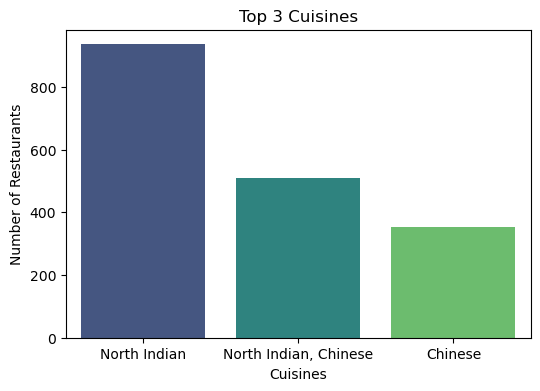

In [35]:
#  Task 1: Top Cuisines 
top_cuisines = df['Cuisines'].value_counts().head(3)
top_cuisine_percent = (top_cuisines / len(df)) * 100
print("Top 3 Cuisines:\n", top_cuisines)

plt.figure(figsize=(6,4))
sns.barplot(x=top_cuisines.index, y=top_cuisines.values, palette='viridis')
plt.title("Top 3 Cuisines")
plt.ylabel("Number of Restaurants")
plt.show()

C:\Users\gayat\AppData\Local\Temp\ipykernel_4880\1369369688.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index[:10], y=city_counts.values[:10], palette='coolwarm')


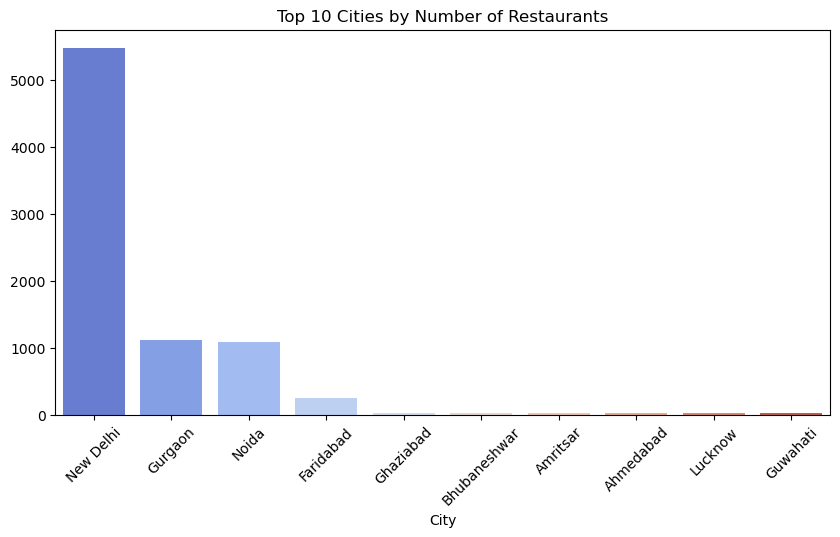

C:\Users\gayat\AppData\Local\Temp\ipykernel_4880\1369369688.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_city.index[:10], y=avg_rating_city.values[:10], palette='magma')


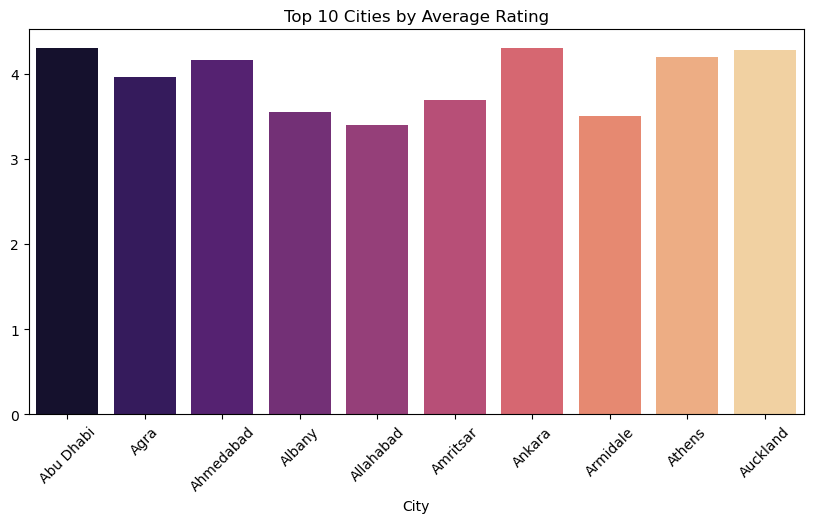

In [37]:
# Task 2: City Analysis 
city_counts = df['City'].value_counts()
avg_rating_city = df.groupby('City')['Rating'].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=city_counts.index[:10], y=city_counts.values[:10], palette='coolwarm')
plt.title("Top 10 Cities by Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x=avg_rating_city.index[:10], y=avg_rating_city.values[:10], palette='magma')
plt.title("Top 10 Cities by Average Rating")
plt.xticks(rotation=45)
plt.show()

C:\Users\gayat\AppData\Local\Temp\ipykernel_4880\2973591456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Price range', data=df, palette='Set2')


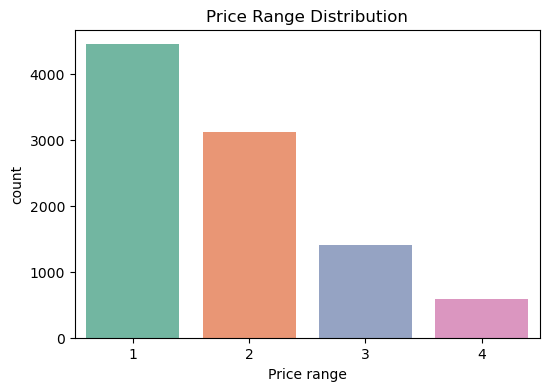

In [39]:
# Task 3: Price Range Distribution 
plt.figure(figsize=(6,4))
sns.countplot(x='Price range', data=df, palette='Set2')
plt.title("Price Range Distribution")
plt.show()

Percentage offering online delivery:
 Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


C:\Users\gayat\AppData\Local\Temp\ipykernel_4880\3962330310.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Has Online delivery', data=df, palette='Set1')


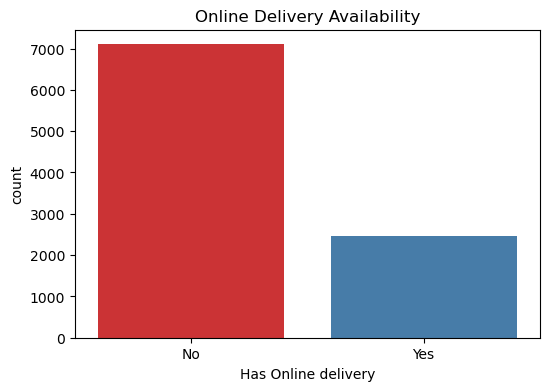

In [41]:
# Task 4: Online Delivery 
online_delivery_percent = (df['Has Online delivery'].value_counts(normalize=True) * 100)
print("Percentage offering online delivery:\n", online_delivery_percent)

plt.figure(figsize=(6,4))
sns.countplot(x='Has Online delivery', data=df, palette='Set1')
plt.title("Online Delivery Availability")
plt.show()

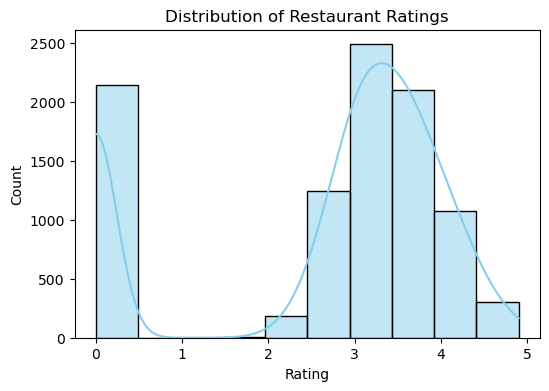

In [43]:
# Task 5: Restaurant Ratings 
plt.figure(figsize=(6,4))
sns.histplot(df['Rating'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Restaurant Ratings")
plt.show()

Most common cuisine combinations:
 [(('North Indian', 'Chinese'), 1516), (('North Indian', 'Mughlai'), 728), (('North Indian', 'Fast Food'), 377), (('Chinese', 'Fast Food'), 331), (('North Indian', 'South Indian'), 314)]


C:\Users\gayat\AppData\Local\Temp\ipykernel_4880\4114755567.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comb_counts, y=comb_names, palette='cool')


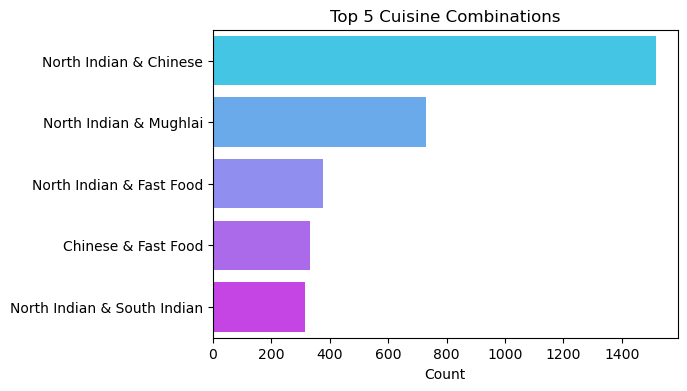

In [47]:
# Task 1: Cuisine Combinations 
df['Cuisine_List'] = df['Cuisines'].dropna().apply(lambda x: [c.strip() for c in x.split(',')])
all_combinations = []
for cuisines in df['Cuisine_List'].dropna():
    if len(cuisines) > 1:
        all_combinations.extend(list(combinations(cuisines, 2)))
comb_counter = Counter(all_combinations)
most_common_comb = comb_counter.most_common(5)
print("Most common cuisine combinations:\n", most_common_comb)
# Visualization of top 5 cuisine combinations
comb_names = [' & '.join([c[0], c[1]]) for c, _ in most_common_comb]
comb_counts = [count for _, count in most_common_comb]
plt.figure(figsize=(6,4))
sns.barplot(x=comb_counts, y=comb_names, palette='cool')
plt.title("Top 5 Cuisine Combinations")
plt.xlabel("Count")
plt.show()

In [51]:
# Task 3: Restaurant Chains 
chains = df['Restaurant Name'].value_counts()
chains_with_multiple = chains[chains > 1]
print("Restaurant chains present:\n", chains_with_multiple)

Restaurant chains present:
 Restaurant Name
Cafe Coffee Day       83
Domino's Pizza        79
Subway                63
Green Chick Chop      51
McDonald's            48
                      ..
Town Hall              2
Halki Aanch            2
Snack Junction         2
Delhi Biryani Hut      2
Beliram Degchiwala     2
Name: count, Length: 734, dtype: int64


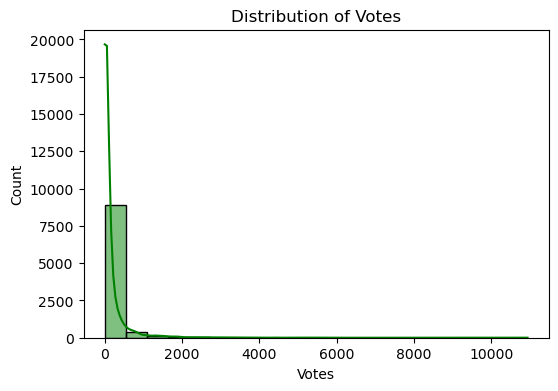

Correlation between Votes and Rating: 0.31369058419541135


In [53]:
# Task 1: Votes Analysis 
plt.figure(figsize=(6,4))
sns.histplot(df['Votes'], bins=20, kde=True, color='green')
plt.title("Distribution of Votes")
plt.show()

votes_rating_corr = df['Votes'].corr(df['Rating'])
print("Correlation between Votes and Rating:", votes_rating_corr)

             Has Online delivery  Has Table booking
Price range                                        
1                       0.157741           0.000225
2                       0.413106           0.076775
3                       0.291903           0.457386
4                       0.090444           0.467577


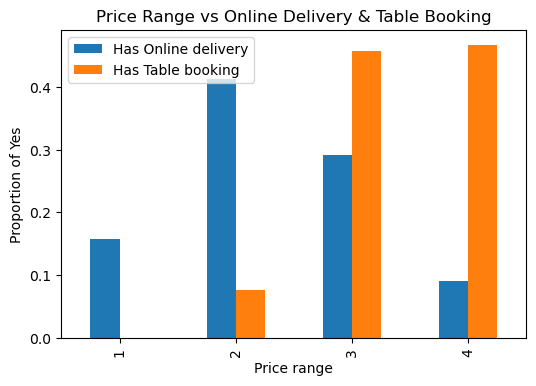

In [55]:
#Task 2: Price Range vs. Online Delivery & Table Booking 
price_online_table = df.groupby('Price range')[['Has Online delivery','Has Table booking']].apply(lambda x: (x=='Yes').mean())
print(price_online_table)

price_online_table.plot(kind='bar', figsize=(6,4))
plt.title("Price Range vs Online Delivery & Table Booking")
plt.ylabel("Proportion of Yes")
plt.show()